# Inputs

In [3]:
import pandas as pd
import numpy as np
import altair as alt

ModuleNotFoundError: No module named 'pandas'

# Dataset SFC (Solo crédito productivo)

In [ ]:
!gdown --id '1pqULCPNUfiZ1H9bvtahu2gJOBbHPnVMr' --output datos.csv

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1pqULCPNUfiZ1H9bvtahu2gJOBbHPnVMr
From (redirected): https://drive.google.com/uc?id=1pqULCPNUfiZ1H9bvtahu2gJOBbHPnVMr&confirm=t&uuid=2c49896a-991c-42de-b99a-51a7a08b7960
To: /content/datos.csv
100% 1.55G/1.55G [00:15<00:00, 99.7MB/s]


In [ ]:
#https://drive.google.com/file/d/1pqULCPNUfiZ1O9ODFOtBUg_cR0j7s4rS/edit?gid=507069586#gid=507069586
#ID: 17nXNQBaf2gi1O9ODFOtBUg_cR0j7s4rS
df = pd.read_csv('datos.csv')

In [ ]:
df['producto_de_cr_dito'].unique()

array(['Crédito productivo de mayor monto (sin recursos de redescuento)',
       'Crédito popular productivo urbano (sin recursos de redescuento)',
       'Crédito productivo rural (sin recursos de redescuento)',
       'Crédito popular productivo rural (sin recursos de redescuento)',
       'Crédito productivo urbano (sin recursos de redescuento)',
       'Crédito productivo urbano  (con recursos de redescuento)',
       'Crédito popular productivo urbano  (con recursos de redescuento)',
       'Crédito productivo rural  (con recursos de redescuento)',
       'Crédito productivo de mayor monto (con recursos de redescuento)',
       'Crédito popular productivo rural (con recursos de redescuento)'],
      dtype=object)

In [ ]:
df['producto_de_credito_red'] = df['producto_de_cr_dito'].replace({
    'Crédito productivo urbano (sin recursos de redescuento)': 'Crédito productivo urbano',
    'Crédito productivo urbano  (con recursos de redescuento)': 'Crédito productivo urbano',
    'Crédito productivo rural (sin recursos de redescuento)': 'Crédito productivo rural',
    'Crédito productivo rural  (con recursos de redescuento)': 'Crédito productivo rural',
    'Crédito popular productivo urbano (sin recursos de redescuento)': 'Crédito popular productivo urbano',
    'Crédito popular productivo urbano  (con recursos de redescuento)': 'Crédito popular productivo urbano',
    'Crédito popular productivo rural (sin recursos de redescuento)': 'Crédito popular productivo rural',
    'Crédito popular productivo rural (con recursos de redescuento)': 'Crédito popular productivo rural',
    'Crédito productivo de mayor monto (sin recursos de redescuento)': 'Crédito productivo de mayor monto',
    'Crédito productivo de mayor monto (con recursos de redescuento)': 'Crédito productivo de mayor monto',
})

<Axes: xlabel='producto_de_credito_red'>

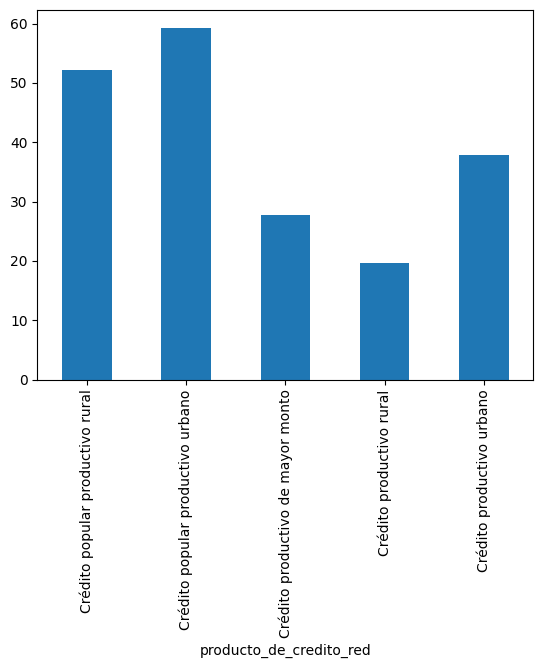

In [ ]:
df.groupby('producto_de_credito_red')['tasa_efectiva_promedio'].mean().plot.bar()

In [ ]:
grouped_by_producto_credito = df.groupby(['year_month', 'producto_de_credito_red']).agg(
    numero_de_creditos=('numero_de_creditos', 'sum'),
    montos_desembolsados=('montos_desembolsados', 'sum')
).reset_index()

monthly_totals = df.groupby('year_month').agg(
    total_numero_de_creditos=('numero_de_creditos', 'sum'),
    total_montos_desembolsados=('montos_desembolsados', 'sum')
).reset_index()

proportions_by_producto_credito_red = pd.merge(
    grouped_by_producto_credito,
    monthly_totals,
    on='year_month',
    how='left'
)

proportions_by_producto_credito_red['prop_numero_de_creditos'] = proportions_by_producto_credito_red['numero_de_creditos'] / proportions_by_producto_credito_red['total_numero_de_creditos']
proportions_by_producto_credito_red['prop_montos_desembolsados'] = proportions_by_producto_credito_red['montos_desembolsados'] / proportions_by_producto_credito_red['total_montos_desembolsados']

proportions_by_producto_credito_red.head()

,year_month,producto_de_credito_red,numero_de_creditos,montos_desembolsados,total_numero_de_creditos,total_montos_desembolsados,prop_numero_de_creditos,prop_montos_desembolsados
0,2023-09,Crédito popular productivo rural,3881,1.315892e+10,32474,3.026789e+11,0.119511,0.043475
1,2023-09,Crédito popular productivo urbano,15495,4.895419e+10,32474,3.026789e+11,0.477151,0.161736
2,2023-09,Crédito productivo de mayor monto,2052,9.248671e+10,32474,3.026789e+11,0.063189,0.305560
3,2023-09,Crédito productivo rural,3693,5.156090e+10,32474,3.026789e+11,0.113722,0.170349
4,2023-09,Crédito productivo urbano,7353,9.651817e+10,32474,3.026789e+11,0.226427,0.318880


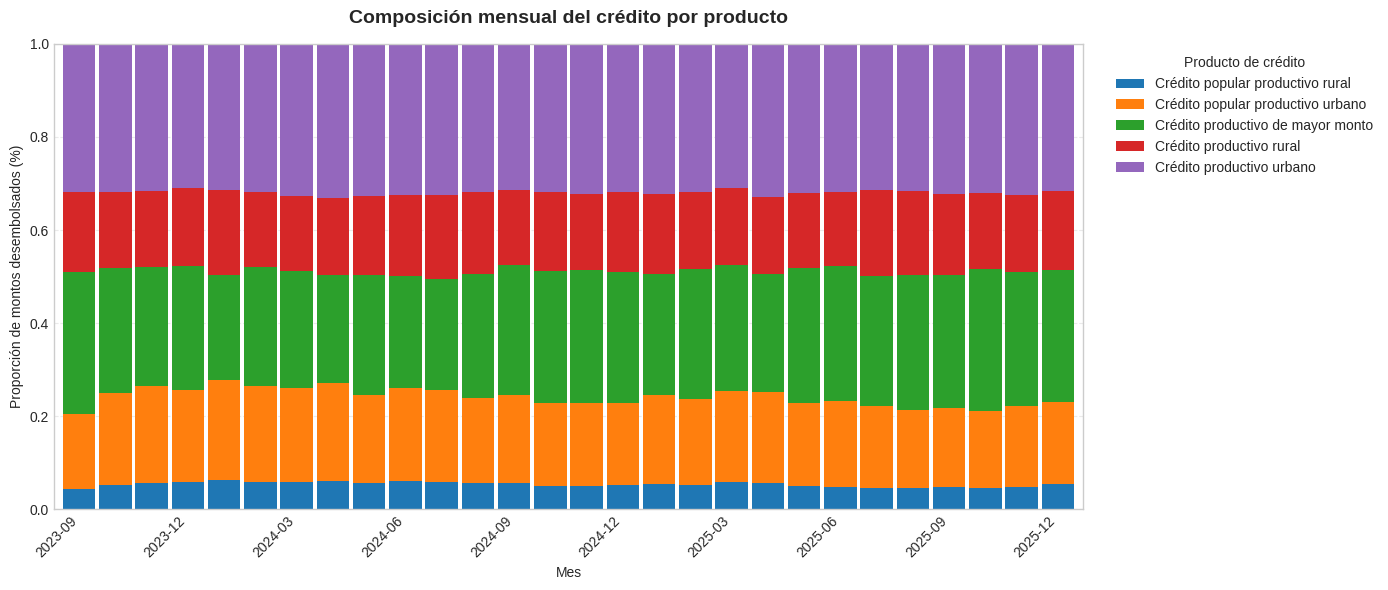

In [ ]:
import matplotlib.pyplot as plt

# 1) Pivot directo (NO volver a agregar proporciones)
pivot = (
    proportions_by_producto_credito_red
    .pivot_table(
        index="year_month",
        columns="producto_de_credito_red",
        values="prop_montos_desembolsados",
        aggfunc="mean"   # o 'sum' si sabes que no hay duplicados por mes-producto
    )
    .sort_index()
)

# 2) Plot barras apiladas
plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(14, 6))

pivot.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    width=0.9
)

# 3) Estilo académico
ax.set_title(
    "Composición mensual del crédito por producto",
    fontsize=14,
    weight="bold",
    pad=15
)
ax.set_xlabel("Mes")
ax.set_ylabel("Proporción de montos desembolsados (%)")
ax.set_ylim(0, 1)  # si está en [0,1]

ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.grid(axis="x", visible=False)

# Submuestreo eje X
ax.set_xticks(range(len(pivot.index)))
ax.set_xticklabels(
    [m if i % 3 == 0 else "" for i, m in enumerate(pivot.index)],
    rotation=45,
    ha="right"
)

# Leyenda fuera
ax.legend(
    title="Producto de crédito",
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


In [ ]:
df['year_month'] = pd.to_datetime(df['fecha_corte']).dt.to_period('M')

In [ ]:
def add_flags(frame: pd.DataFrame) -> pd.DataFrame:
    """
    Crea columnas binarias de identificación:
      - garantia_flag: 1 si el crédito tiene alguna garantía (FAG u otra), 0 si no.
      - rural_flag: 1 si el crédito pertenece a un municipio rural, 0 si no.

    Ajusta las condiciones según la codificación real de tu dataset.
    """
    f = frame.copy()

    # ------- Garantía -------
    col_g = "tipo_de_garant_a"
    if col_g in f.columns:
        g_str = f[col_g].astype(str).str.upper()
        # Marca 1 si NO dice 'SIN GARANT' o no está vacío
        has_g = (~f[col_g].isna()) & (~g_str.str.contains("FAG", na=False)) # <- agregar ~ y SIN GARANTIA
        f["garantia_flag"] = has_g.astype(int)
    else:
        f["garantia_flag"] = 0  # si no existe la columna, por defecto 0

    # ------- Ruralidad -------
    col_tm = "tipo_municipio"
    if col_tm in f.columns:
        # Cambiado a str.contains para incluir cadenas que contengan 'RURAL'
        f["rural_flag"] = f[col_tm].astype(str).str.upper().str.contains("RURAL", na=False).astype(int)
    else:
        f["rural_flag"] = np.nan  # sin información

    return f

In [ ]:
df = add_flags(df)

In [ ]:
df = df.reset_index(drop=True)

In [ ]:
df_sfc = df.copy() #solo crédito productivo

# Dataset Finagro (Sin Normalización de cartera)

In [ ]:
from IPython.display import clear_output

In [ ]:
!gdown --fuzzy 'https://drive.google.com/file/d/1KMwal7BjIhbOV2k4UC1duRqQXrEM5Gxi/view?usp=drive_link' --output dataset_finagro.csv

Downloading...
From (original): https://drive.google.com/uc?id=1KMwal7BjIhbOV2k4UC1duRqQXrEM5Gxi
From (redirected): https://drive.google.com/uc?id=1KMwal7BjIhbOV2k4UC1duRqQXrEM5Gxi&confirm=t&uuid=2ff4cf96-6bd9-4848-9b0c-6f5be7742e13
To: /content/dataset_finagro.csv
100% 363M/363M [00:03<00:00, 108MB/s] 


In [ ]:
df_pandas = pd.read_csv('dataset_finagro.csv', dtype = {'cod_municipio': str, 'cod_departamento': str})

In [ ]:
# Verificar categorías únicas primero
print(df_pandas['tipo_municipio'].unique())

['Intermedio' 'Ciudades y aglomeraciones' 'Rural disperso' 'Rural']


In [ ]:
# Reemplazo explícito
df_pandas['tipo_municipio'] = df_pandas['tipo_municipio'].replace({
    'Rural disperso': 'Rural',
    'Ciudades y aglomeraciones': 'Urbano',
    'Intermedio': 'Urbano'
})

In [ ]:
df_pandas.head()

,id_credito,fecha_credito,cod_municipio,tipo_cartera,tipo_intermediario,tipo_productor,tipo_beneficiario,tipo_persona,sexo,cod_destino,...,indicador_lec,valor_subsidio,nuevo,cod_departamento,nombre_departamento,nombre_municipio,tipo_municipio,tasa_indexacion_valor,tasa_credito,tasa_credito_new
0,2350103751,2023-01-05,5887,Redescuento,Bancos,Pequeño,Pequeño productor,Natural,Hombre,253050,...,False,0,True,5,ANTIOQUIA,YARUMAL,Urbano,12.869376,17.917881,17.180
1,2350127280,2023-01-30,52083,Redescuento,Bancos,Pequeño,Pequeño productor,Natural,Hombre,900001,...,False,0,False,52,NARIÑO,BELÉN,Urbano,12.633951,17.861196,16.776
2,2302529983,2023-01-30,25126,Sustitutiva,Bancos,Mediano,Mediano productor,Jurídica,NaN,408011,...,False,0,True,25,CUNDINAMARCA,CAJICÁ,Urbano,12.547581,23.603404,21.379
3,2350117950,2023-01-20,68245,Redescuento,Bancos,Pequeño,Pequeño productor,Natural,Hombre,253000,...,False,0,True,68,SANTANDER,EL GUACAMAYO,Rural,12.827946,17.875535,17.141
4,2350104346,2023-01-05,41006,Redescuento,Bancos,Pequeño,Pequeño productor,Natural,Mujer,347050,...,False,0,False,41,HUILA,ACEVEDO,Rural,12.869376,17.917881,17.180


In [ ]:
df_pandas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1107953 entries, 0 to 1107952
Data columns (total 34 columns):
 #   Column                        Non-Null Count    Dtype  
---  ------                        --------------    -----  
 0   id_credito                    1107953 non-null  int64  
 1   fecha_credito                 1107953 non-null  object 
 2   cod_municipio                 1107953 non-null  object 
 3   tipo_cartera                  1107953 non-null  object 
 4   tipo_intermediario            1107953 non-null  object 
 5   tipo_productor                1107953 non-null  object 
 6   tipo_beneficiario             1107953 non-null  object 
 7   tipo_persona                  1107936 non-null  object 
 8   sexo                          1035723 non-null  object 
 9   cod_destino                   1107953 non-null  int64  
 10  linea_credito                 1107953 non-null  object 
 11  cadena                        1107953 non-null  object 
 12  eslabon_cadena              

In [ ]:
df_finagro = df_pandas[df_pandas['linea_credito'] != 'Normalización de Cartera'].copy()

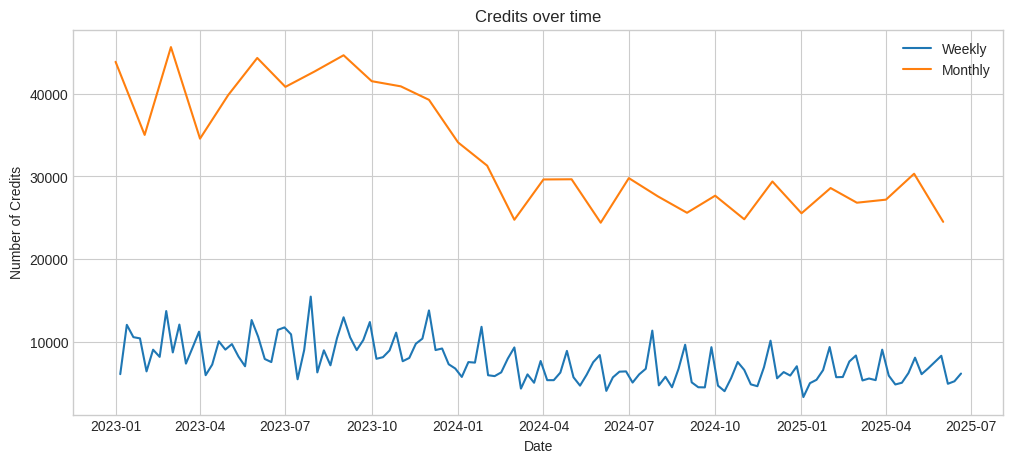

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# --- fechas ---
df_finagro['fecha_credito'] = pd.to_datetime(df_finagro['fecha_credito'])

# --- semana iniciando viernes ---
df_finagro['week'] = (
    df_finagro['fecha_credito']
    - pd.to_timedelta((df_finagro['fecha_credito'].dt.weekday - 4) % 7, unit='D')
).dt.floor('D')

# --- mes ---
df_finagro['month'] = df_finagro['fecha_credito'].dt.to_period('M').dt.start_time

# --- agregaciones ---
weekly_credits = (
    df_finagro.groupby('week')['id_credito']
    .count()
    .sort_index()
)

monthly_credits = (
    df_finagro.groupby('month')['id_credito']
    .count()
    .sort_index()
)

# opcional: quitar semanas incompletas
weekly_credits = weekly_credits.iloc[1:-1]

# --- plot ---
plt.figure(figsize=(12,5))
plt.plot(weekly_credits.index, weekly_credits.values, label='Weekly')
plt.plot(monthly_credits.index, monthly_credits.values, label='Monthly')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Number of Credits')
plt.title('Credits over time')
plt.show()

In [ ]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
weekly_credits

,id_credito
week,
2023-01-06,6085
2023-01-13,12050
2023-01-20,10561
2023-01-27,10414
2023-02-03,6421
2023-02-10,9044
2023-02-17,8176
2023-02-24,13717
2023-03-03,8711


In [ ]:
df_finagro['nombre_programa'].value_counts().head(20)

,count
nombre_programa,
IBR CREDITO ORDINARIO,505935
IBR MICROCREDITO AGROPECUARIO Y RURAL,105628
IBR TARJETA AGROPECUARIA,104547
IBR FINANCIACIÓN PROYECTOS EJECUTADOS POBLACIÓN EN SITUACIÓN ESPECIAL,76909
IBR LEC 2024 DESARROLLO PRODUCTIVO N2,45342
IBR LEC 2023 DESARROLLO PRODUCTIVO,41017
IBR LEC 2023 MUJER RURAL,19267
IBR MICROCREDITO GLOBAL,14138
IBR LEASING FINANCIERO,8979


# Consolidación

In [ ]:
df_finagro.info()

<class 'pandas.core.frame.DataFrame'>
Index: 994954 entries, 0 to 1107950
Data columns (total 36 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   id_credito                    994954 non-null  int64         
 1   fecha_credito                 994954 non-null  datetime64[ns]
 2   cod_municipio                 994954 non-null  object        
 3   tipo_cartera                  994954 non-null  object        
 4   tipo_intermediario            994954 non-null  object        
 5   tipo_productor                994954 non-null  object        
 6   tipo_beneficiario             994954 non-null  object        
 7   tipo_persona                  994937 non-null  object        
 8   sexo                          925763 non-null  object        
 9   cod_destino                   994954 non-null  int64         
 10  linea_credito                 994954 non-null  object        
 11  cadena           

In [ ]:
df_sfc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3339047 entries, 0 to 3339046
Data columns (total 37 columns):
 #   Column                    Dtype    
---  ------                    -----    
 0   tipo_entidad              int64    
 1   nombre_tipo_entidad       object   
 2   codigo_entidad            int64    
 3   nombre_entidad            object   
 4   fecha_corte               object   
 5   tipo_de_persona           object   
 6   sexo                      object   
 7   tama_o_de_empresa         object   
 8   tipo_de_cr_dito           object   
 9   tipo_de_garant_a          object   
 10  producto_de_cr_dito       object   
 11  plazo_de_cr_dito          object   
 12  tasa_efectiva_promedio    float64  
 13  margen_adicional_a_la     float64  
 14  montos_desembolsados      float64  
 15  numero_de_creditos        int64    
 16  grupo_etnico              object   
 17  antiguedad_de_la_empresa  object   
 18  tipo_de_tasa              object   
 19  rango_monto_desembols

## Finagro en SFC
Reglas:

Lower bound: Rural Redescuento y FAG

Upper Bound: Rural con redescuento o FAG

In [ ]:
df["tipo_de_garant_a"].unique()

array(['Sin garantia', 'Garantia idónea o no idónea',
       'Garantía  fondo nacional de garantías (FNG) o Fondo de Garantías de Antioquia (FGA)',
       'Garantía del fondo agropecuario de garantías (FAG)',
       'Garantía fondo nacional de garantías (FNG)',
       'Garantía fondo de garantías de Antioquia (FGA)'], dtype=object)

### Bounds

In [ ]:
import pandas as pd
import numpy as np

# =========================
# Copia y limpieza básica
# =========================
df = df_sfc.copy()

# fecha semanal SFC (viernes)
df["fecha_corte"] = pd.to_datetime(df["fecha_corte"], errors="coerce")

# normalizar texto
for col in ["producto_de_cr_dito", "tipo_de_garant_a"]:
    df[col] = df[col].astype(str).str.strip().str.lower()

# asegurar numéricos
df["numero_de_creditos"] = pd.to_numeric(df["numero_de_creditos"], errors="coerce").fillna(0)
df["montos_desembolsados"] = pd.to_numeric(df["montos_desembolsados"], errors="coerce").fillna(0)

# =========================
# Flags base
# =========================
df["is_redescuento"] = df["producto_de_cr_dito"].str.contains("con recursos de redescuento", na=False)
df["is_fag"] = df["tipo_de_garant_a"].str.contains("fag", na=False)
df["is_fng"] = df["tipo_de_garant_a"].astype(str).str.lower().str.contains(
    "fng|fondo nacional de garant", na=False
)

# opcional: solo rural
df["is_rural"] = df["producto_de_cr_dito"].str.contains("rural", na=False)

# =========================
# Bounds
# =========================
# Lower bound conservador
df["is_finagro_lb"] = df["is_fag"] & df["is_redescuento"]

# Upper bound amplio
df["is_finagro_ub"] = (~df["is_fng"]) & (df["is_redescuento"])

# =========================
# Agregación semanal
# =========================
weekly_bounds = (
    df.groupby("fecha_corte", as_index=False)
      .agg(
          total_creditos=("numero_de_creditos", "sum"),
          total_montos=("montos_desembolsados", "sum"),

          lb_creditos=("numero_de_creditos", lambda x: x[df.loc[x.index, "is_finagro_lb"]].sum()),
          lb_montos=("montos_desembolsados", lambda x: x[df.loc[x.index, "is_finagro_lb"]].sum()),

          ub_creditos=("numero_de_creditos", lambda x: x[df.loc[x.index, "is_finagro_ub"]].sum()),
          ub_montos=("montos_desembolsados", lambda x: x[df.loc[x.index, "is_finagro_ub"]].sum())
      )
      .sort_values("fecha_corte")
)

# porcentajes
weekly_bounds["lb_pct_creditos"] = weekly_bounds["lb_creditos"] / weekly_bounds["total_creditos"]
weekly_bounds["ub_pct_creditos"] = weekly_bounds["ub_creditos"] / weekly_bounds["total_creditos"]

weekly_bounds["lb_pct_montos"] = weekly_bounds["lb_montos"] / weekly_bounds["total_montos"]
weekly_bounds["ub_pct_montos"] = weekly_bounds["ub_montos"] / weekly_bounds["total_montos"]

# en porcentaje %
pct_cols = ["lb_pct_creditos", "ub_pct_creditos", "lb_pct_montos", "ub_pct_montos"]
weekly_bounds[pct_cols] = weekly_bounds[pct_cols] * 100

In [ ]:
weekly_bounds

,fecha_corte,total_creditos,total_montos,lb_creditos,lb_montos,ub_creditos,ub_montos,lb_pct_creditos,ub_pct_creditos,lb_pct_montos,ub_pct_montos
0,2023-09-29,32474,3.026789e+11,6922,9.400943e+10,7153,1.028023e+11,21.315514,22.026852,31.059129,33.964157
1,2023-10-06,28193,2.379101e+11,5020,6.603932e+10,5323,8.109176e+10,17.805838,18.880573,27.758100,34.085042
2,2023-10-13,31755,2.480001e+11,4203,5.534107e+10,4443,6.755569e+10,13.235711,13.991497,22.314937,27.240183
3,2023-10-20,24684,2.044331e+11,4089,5.430520e+10,4248,6.144631e+10,16.565386,17.209528,26.563803,30.056932
4,2023-10-27,31853,2.769587e+11,6415,8.578328e+10,6597,9.333827e+10,20.139390,20.710765,30.973313,33.701153
5,2023-11-03,26211,2.342472e+11,4912,6.590047e+10,5130,7.412108e+10,18.740224,19.571935,28.132871,31.642248
6,2023-11-10,26068,1.924001e+11,3926,5.152992e+10,4039,5.549871e+10,15.060611,15.494092,26.782690,28.845468
7,2023-11-17,26109,2.099070e+11,4436,5.891482e+10,4597,6.482435e+10,16.990310,17.606955,28.067108,30.882416
8,2023-11-24,33121,2.645292e+11,5497,7.363989e+10,5692,8.073298e+10,16.596721,17.185471,27.838097,30.519501
9,2023-12-01,34658,3.082470e+11,7209,9.622120e+10,7498,1.079619e+11,20.800392,21.634255,31.215615,35.024487


In [ ]:
grouped_sfc = df_sfc.groupby(['fecha_corte', 'producto_de_credito_red']).agg(
    total_creditos=('numero_de_creditos', 'sum'),
    total_montos=('montos_desembolsados', 'sum'),
    lb_creditos=('numero_de_creditos', lambda x: x[df.loc[x.index, 'is_finagro_lb']].sum()),
    lb_montos=('montos_desembolsados', lambda x: x[df.loc[x.index, 'is_finagro_lb']].sum()),
    ub_creditos=('numero_de_creditos', lambda x: x[df.loc[x.index, 'is_finagro_ub']].sum()),
    ub_montos=('montos_desembolsados', lambda x: x[df.loc[x.index, 'is_finagro_ub']].sum())
).reset_index()

grouped_sfc['lb_pct_creditos'] = (grouped_sfc['lb_creditos'] / grouped_sfc['total_creditos'] * 100).fillna(0)
grouped_sfc['ub_pct_creditos'] = (grouped_sfc['ub_creditos'] / grouped_sfc['total_creditos'] * 100).fillna(0)
grouped_sfc['lb_pct_montos'] = (grouped_sfc['lb_montos'] / grouped_sfc['total_montos'] * 100).fillna(0)
grouped_sfc['ub_pct_montos'] = (grouped_sfc['ub_montos'] / grouped_sfc['total_montos'] * 100).fillna(0)

grouped_sfc

,fecha_corte,producto_de_credito_red,total_creditos,total_montos,lb_creditos,lb_montos,ub_creditos,ub_montos,lb_pct_creditos,ub_pct_creditos,lb_pct_montos,ub_pct_montos
0,2023-09-29,Crédito popular productivo rural,3881,1.315892e+10,972,4.001975e+09,978,4.030857e+09,25.045091,25.199691,30.412651,30.632137
1,2023-09-29,Crédito popular productivo urbano,15495,4.895419e+10,838,3.509224e+09,842,3.529614e+09,5.408196,5.434011,7.168384,7.210035
2,2023-09-29,Crédito productivo de mayor monto,2052,9.248671e+10,526,1.990140e+10,662,2.722376e+10,25.633528,32.261209,21.518119,29.435321
3,2023-09-29,Crédito productivo rural,3693,5.156090e+10,2726,3.969102e+10,2773,4.049039e+10,73.815326,75.088004,76.978907,78.529256
4,2023-09-29,Crédito productivo urbano,7353,9.651817e+10,1860,2.690581e+10,1898,2.752771e+10,25.295798,25.812593,27.876416,28.520751
5,2023-10-06,Crédito popular productivo rural,3474,1.170909e+10,722,2.967843e+09,727,2.988623e+09,20.782959,20.926885,25.346496,25.523965
6,2023-10-06,Crédito popular productivo urbano,14606,4.576918e+10,642,2.672608e+09,647,2.700808e+09,4.395454,4.429686,5.839319,5.900932
7,2023-10-06,Crédito productivo de mayor monto,1468,6.685766e+10,326,1.210329e+10,555,2.606296e+10,22.207084,37.806540,18.103066,38.982765
8,2023-10-06,Crédito productivo rural,2777,3.830709e+10,1986,2.895328e+10,2025,2.956239e+10,71.516024,72.920418,75.582037,77.172114
9,2023-10-06,Crédito productivo urbano,5868,7.526707e+10,1344,1.934230e+10,1369,1.977697e+10,22.903885,23.329925,25.698224,26.275720


In [ ]:
df_sfc_aggregated = df_sfc.groupby(['producto_de_cr_dito', 'tipo_de_garant_a']).agg(
    total_numero_de_creditos=('numero_de_creditos', 'sum'),
    total_montos_desembolsados=('montos_desembolsados', 'sum')
).reset_index()

df_sfc_aggregated

,producto_de_cr_dito,tipo_de_garant_a,total_numero_de_creditos,total_montos_desembolsados
0,Crédito popular productivo rural (con recursos...,Garantia idónea o no idónea,8950,3.386748e+10
1,Crédito popular productivo rural (con recursos...,Garantía fondo nacional de garantías (FNG) o ...,143,5.497900e+08
2,Crédito popular productivo rural (con recursos...,Garantía del fondo agropecuario de garantías (...,67552,3.384379e+11
3,Crédito popular productivo rural (con recursos...,Garantía fondo nacional de garantías (FNG),120,7.456400e+08
4,Crédito popular productivo rural (con recursos...,Sin garantia,27,8.680300e+07
5,Crédito popular productivo rural (sin recursos...,Garantia idónea o no idónea,114688,3.847603e+11
6,Crédito popular productivo rural (sin recursos...,Garantía fondo nacional de garantías (FNG) o ...,119042,4.571442e+11
7,Crédito popular productivo rural (sin recursos...,Garantía del fondo agropecuario de garantías (...,3072,1.004965e+10
8,Crédito popular productivo rural (sin recursos...,Garantía fondo de garantías de Antioquia (FGA),2805,9.820532e+09
9,Crédito popular productivo rural (sin recursos...,Garantía fondo nacional de garantías (FNG),14166,5.828034e+10


### Visualizaciones de apoyo

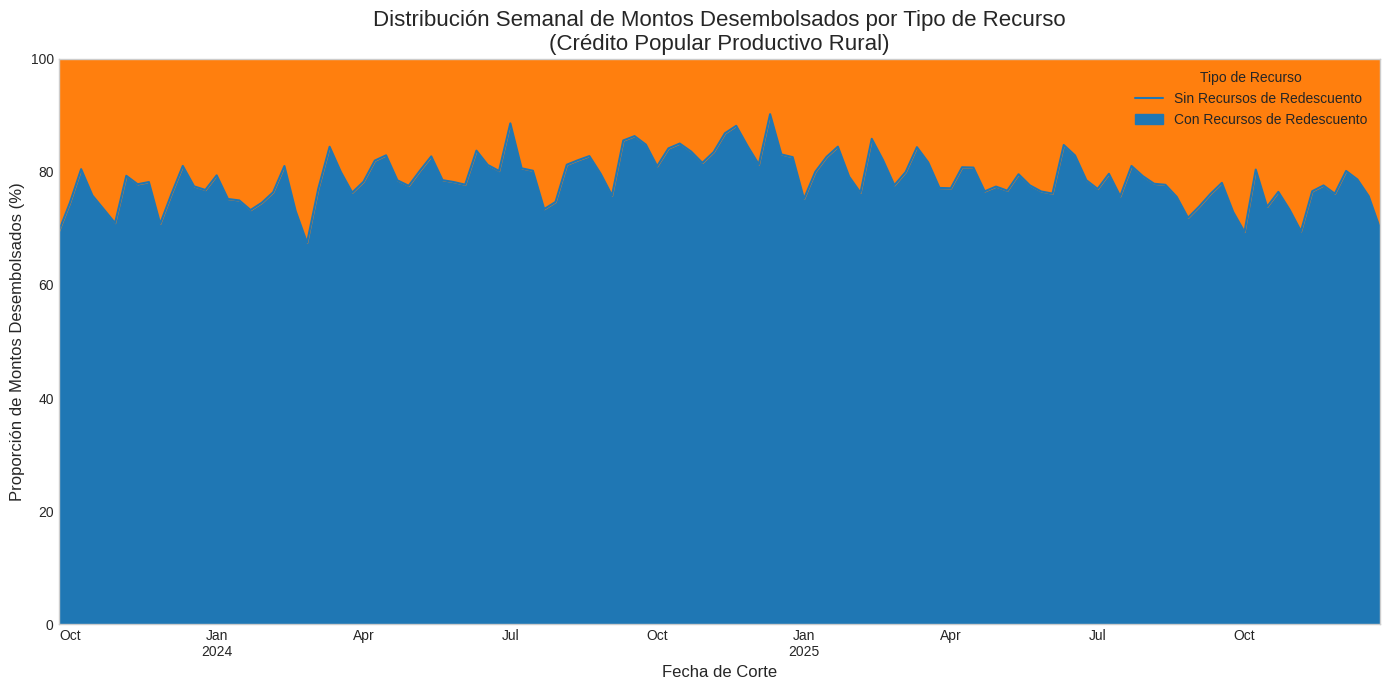

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for 'Crédito popular productivo rural'
df_filtered_rural = df[df['producto_de_credito_red'] == 'Crédito popular productivo rural'].copy()

# Group by date and is_redescuento, sum disbursed amounts
grouped_data = df_filtered_rural.groupby(['fecha_corte', 'is_redescuento'])['montos_desembolsados'].sum().unstack(fill_value=0)

# Calculate total montos_desembolsados for each date
grouped_data['total_montos'] = grouped_data[False] + grouped_data[True]

# Calculate percentages
grouped_data['pct_sin_redescuento'] = (grouped_data[False] / grouped_data['total_montos']) * 100
grouped_data['pct_con_redescuento'] = (grouped_data[True] / grouped_data['total_montos']) * 100

# Select relevant columns for plotting
plot_data = grouped_data[['pct_sin_redescuento', 'pct_con_redescuento']]

# Plotting
plt.figure(figsize=(14, 7))
plot_data.plot(kind='area', stacked=True, ax=plt.gca())

plt.title('Distribución Semanal de Montos Desembolsados por Tipo de Recurso\n(Crédito Popular Productivo Rural)', fontsize=16)
plt.xlabel('Fecha de Corte', fontsize=12)
plt.ylabel('Proporción de Montos Desembolsados (%)', fontsize=12)
plt.ylim(0, 100)
plt.legend(title='Tipo de Recurso', labels=['Sin Recursos de Redescuento', 'Con Recursos de Redescuento'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

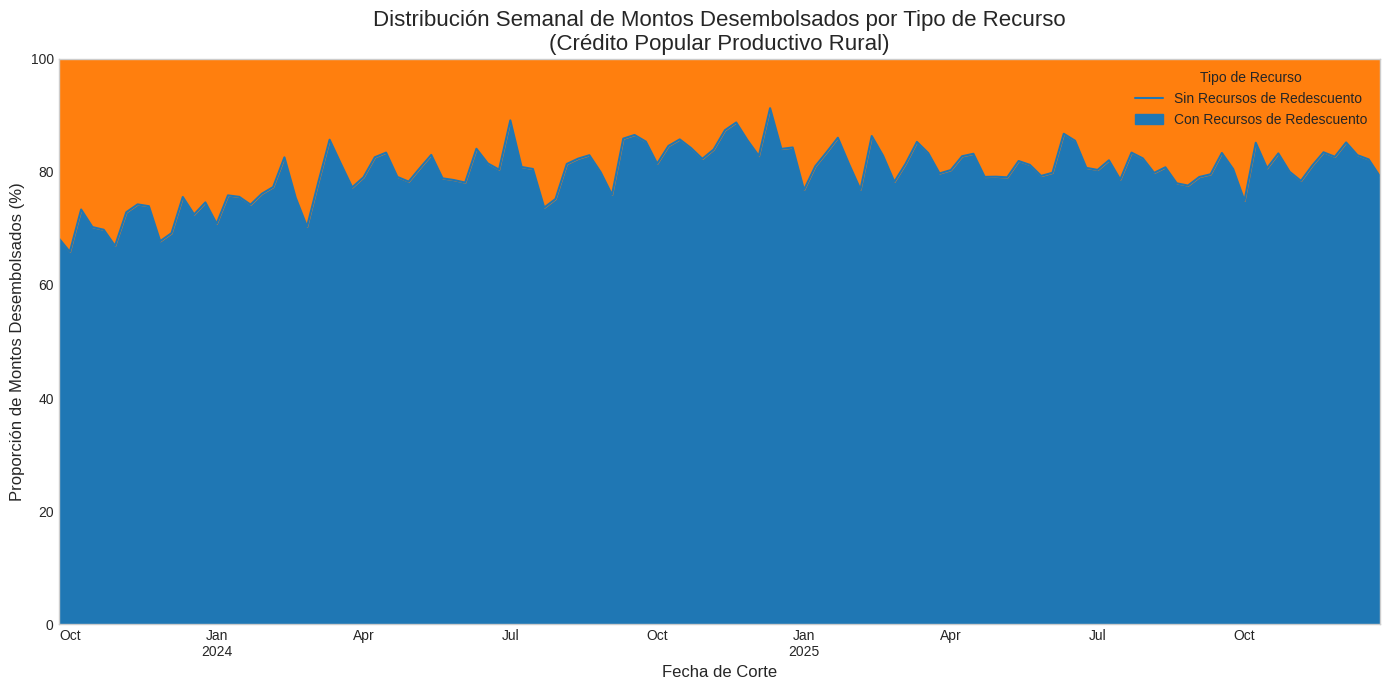

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for 'Crédito popular productivo rural'
df_filtered_rural = df[df['producto_de_credito_red'] == 'Crédito popular productivo rural'].copy()

# Group by date and is_fag, sum disbursed amounts
grouped_data = df_filtered_rural.groupby(['fecha_corte', 'is_fag'])['montos_desembolsados'].sum().unstack(fill_value=0)

# Calculate total montos_desembolsados for each date
grouped_data['total_montos'] = grouped_data[False] + grouped_data[True]

# Calculate percentages
grouped_data['pct_sin_redescuento'] = (grouped_data[False] / grouped_data['total_montos']) * 100
grouped_data['pct_con_redescuento'] = (grouped_data[True] / grouped_data['total_montos']) * 100

# Select relevant columns for plotting
plot_data = grouped_data[['pct_sin_redescuento', 'pct_con_redescuento']]

# Plotting
plt.figure(figsize=(14, 7))
plot_data.plot(kind='area', stacked=True, ax=plt.gca())

plt.title('Distribución Semanal de Montos Desembolsados por Tipo de Recurso\n(Crédito Popular Productivo Rural)', fontsize=16)
plt.xlabel('Fecha de Corte', fontsize=12)
plt.ylabel('Proporción de Montos Desembolsados (%)', fontsize=12)
plt.ylim(0, 100)
plt.legend(title='Tipo de Recurso', labels=['Sin Recursos de Redescuento', 'Con Recursos de Redescuento'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

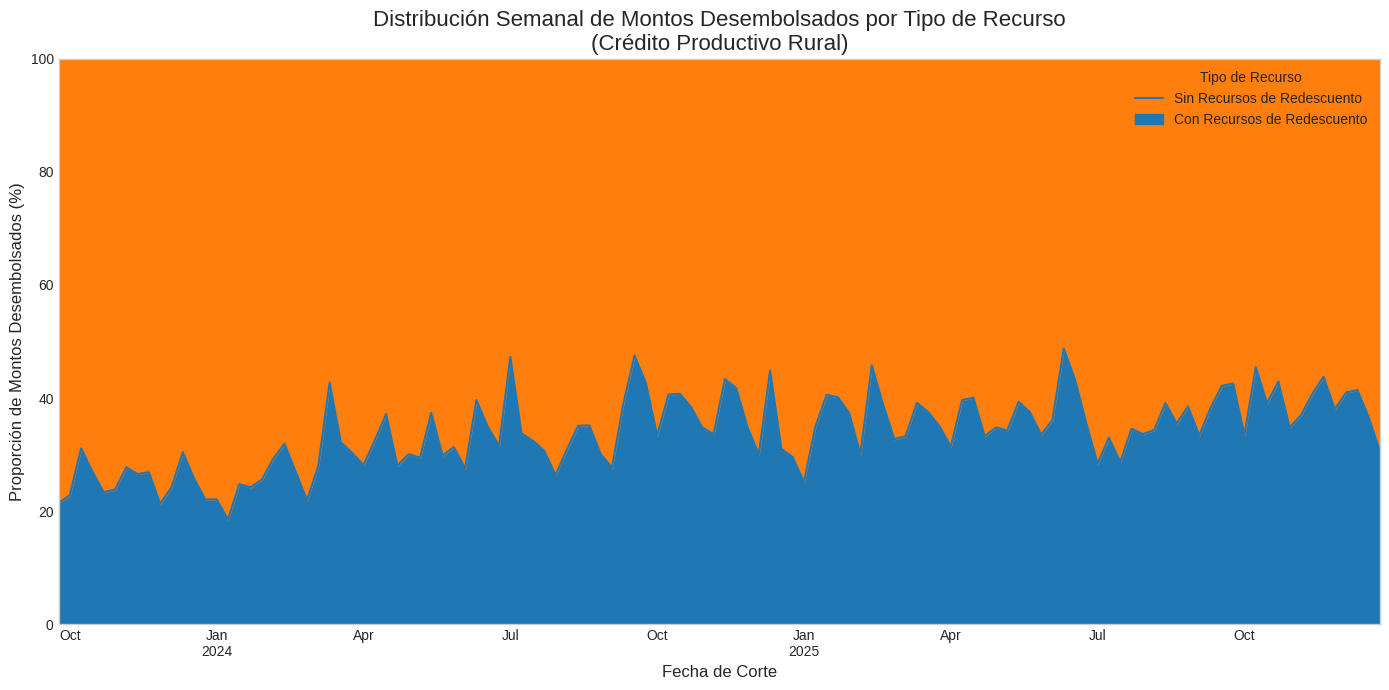

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for 'Crédito productivo rural'
df_filtered_rural = df[df['producto_de_credito_red'] == 'Crédito productivo rural'].copy()

# Group by date and is_redescuento, sum disbursed amounts
grouped_data = df_filtered_rural.groupby(['fecha_corte', 'is_redescuento'])['montos_desembolsados'].sum().unstack(fill_value=0)

# Calculate total montos_desembolsados for each date
grouped_data['total_montos'] = grouped_data[False] + grouped_data[True]

# Calculate percentages
grouped_data['pct_sin_redescuento'] = (grouped_data[False] / grouped_data['total_montos']) * 100
grouped_data['pct_con_redescuento'] = (grouped_data[True] / grouped_data['total_montos']) * 100

# Select relevant columns for plotting
plot_data = grouped_data[['pct_sin_redescuento', 'pct_con_redescuento']]

# Plotting
plt.figure(figsize=(14, 7))
plot_data.plot(kind='area', stacked=True, ax=plt.gca())

plt.title('Distribución Semanal de Montos Desembolsados por Tipo de Recurso\n(Crédito Productivo Rural)', fontsize=16)
plt.xlabel('Fecha de Corte', fontsize=12)
plt.ylabel('Proporción de Montos Desembolsados (%)', fontsize=12)
plt.ylim(0, 100)
plt.legend(title='Tipo de Recurso', labels=['Sin Recursos de Redescuento', 'Con Recursos de Redescuento'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

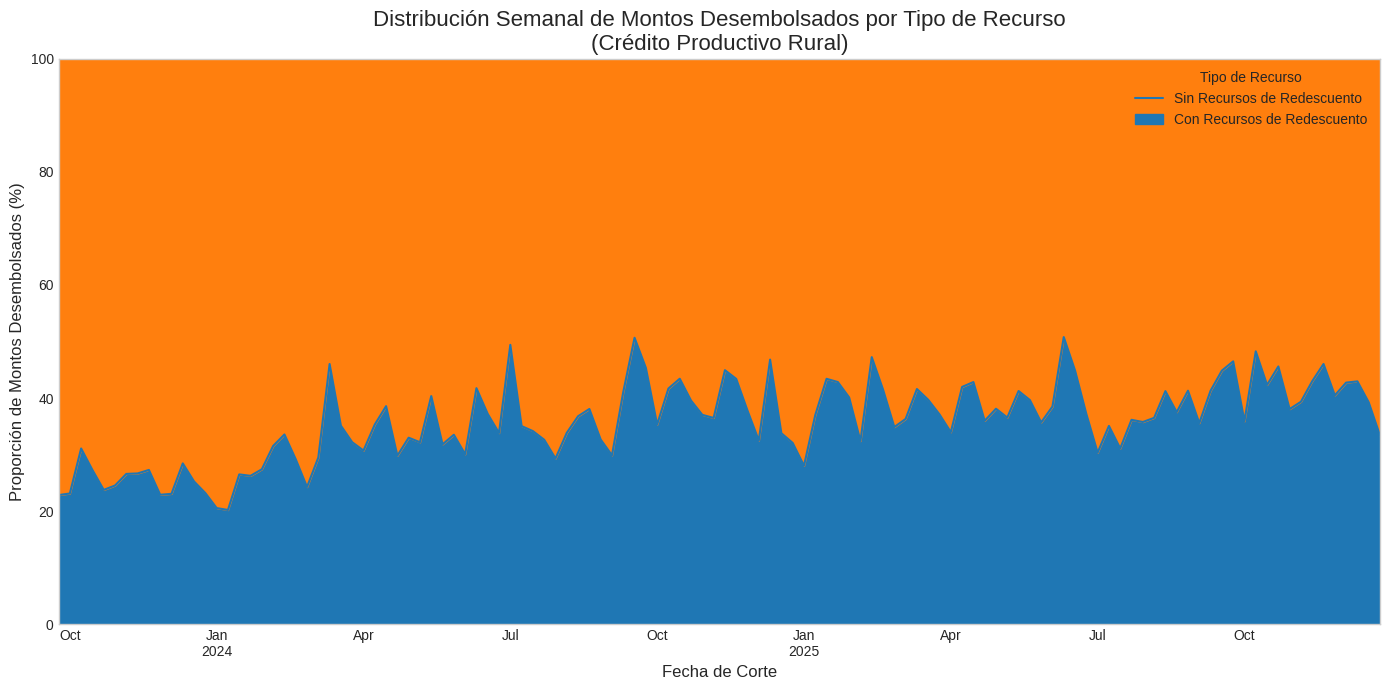

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for 'Crédito productivo rural'
df_filtered_rural = df[df['producto_de_credito_red'] == 'Crédito productivo rural'].copy()

# Group by date and is_redescuento, sum disbursed amounts
grouped_data = df_filtered_rural.groupby(['fecha_corte', 'is_fag'])['montos_desembolsados'].sum().unstack(fill_value=0)

# Calculate total montos_desembolsados for each date
grouped_data['total_montos'] = grouped_data[False] + grouped_data[True]

# Calculate percentages
grouped_data['pct_sin_redescuento'] = (grouped_data[False] / grouped_data['total_montos']) * 100
grouped_data['pct_con_redescuento'] = (grouped_data[True] / grouped_data['total_montos']) * 100

# Select relevant columns for plotting
plot_data = grouped_data[['pct_sin_redescuento', 'pct_con_redescuento']]

# Plotting
plt.figure(figsize=(14, 7))
plot_data.plot(kind='area', stacked=True, ax=plt.gca())

plt.title('Distribución Semanal de Montos Desembolsados por Tipo de Recurso\n(Crédito Productivo Rural)', fontsize=16)
plt.xlabel('Fecha de Corte', fontsize=12)
plt.ylabel('Proporción de Montos Desembolsados (%)', fontsize=12)
plt.ylim(0, 100)
plt.legend(title='Tipo de Recurso', labels=['Sin Recursos de Redescuento', 'Con Recursos de Redescuento'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Tasas Estimaciones

In [ ]:
df.columns

Index(['tipo_entidad', 'nombre_tipo_entidad', 'codigo_entidad',
       'nombre_entidad', 'fecha_corte', 'tipo_de_persona', 'sexo',
       'tama_o_de_empresa', 'tipo_de_cr_dito', 'tipo_de_garant_a',
       'producto_de_cr_dito', 'plazo_de_cr_dito', 'tasa_efectiva_promedio',
       'margen_adicional_a_la', 'montos_desembolsados', 'numero_de_creditos',
       'grupo_etnico', 'antiguedad_de_la_empresa', 'tipo_de_tasa',
       'rango_monto_desembolsado', 'clase_deudor', 'codigo_ciiu',
       'cod_municipio', 'plazo_de_cr_dito_num', 'tasa_ponderada', 'mes',
       'year', 'year_month', 'costo_credito', 'costo_credito_ponderado',
       'cod_departamento', 'nombre_departamento', 'nombre_municipio',
       'tipo_municipio', 'producto_de_credito_red', 'garantia_flag',
       'rural_flag', 'is_redescuento', 'is_fag', 'is_fng', 'is_rural',
       'is_finagro_lb', 'is_finagro_ub'],
      dtype='object')

In [ ]:
aggregated_data = df.groupby(['producto_de_credito_red', 'is_finagro_lb']).agg(
    average_tasa_efectiva_promedio=('tasa_efectiva_promedio', 'mean'),
    creditos_count=('numero_de_creditos', 'sum'),
    montos_sum=('montos_desembolsados', 'sum'),
)

aggregated_data

average_tasa_efectiva_promedio  \
producto_de_credito_red           is_finagro_lb                                   
Crédito popular productivo rural  False                               58.427945   
                                  True                                13.615280   
Crédito popular productivo urbano False                               60.944856   
                                  True                                13.669479   
Crédito productivo de mayor monto False                               31.631847   
                                  True                                13.445027   
Crédito productivo rural          False                               27.644107   
                                  True                                13.320099   
Crédito productivo urbano         False                               44.016778   
                                  True                                13.411363   

                                                 creditos_count    montos_sum  
producto_de_credito_red           is_finagro_lb                                
Crédito popular productivo rural  False                  404940  1.420911e+12  
                                  True                    67552  3.384379e+11  
Crédito popular productivo urbano False                 1726411  5.819483e+12  
                                  True                    61487  3.062267e+11  
Crédito productivo de mayor monto False                  135099  7.354753e+12  
                                  True                    36662  1.643489e+12  
Crédito productivo rural          False                  145050  2.027360e+12  
                                  True                   206191  3.537605e+12  
Crédito productivo urbano         False                  543610  8.047418e+12  
                                  True                   149334  2.502185e+12

In [ ]:
aggregated_data = df.groupby(['fecha_corte','producto_de_credito_red', 'is_finagro_lb']).agg(
    average_tasa_efectiva_promedio=('tasa_efectiva_promedio', 'mean'),
    creditos_count=('numero_de_creditos', 'sum'),
    montos_sum=('montos_desembolsados', 'sum'),
)

aggregated_data

average_tasa_efectiva_promedio  \
fecha_corte producto_de_credito_red           is_finagro_lb                                   
2023-09-29  Crédito popular productivo rural  False                               48.414416   
                                              True                                12.183808   
            Crédito popular productivo urbano False                               49.400014   
                                              True                                11.847684   
            Crédito productivo de mayor monto False                               32.057943   
                                              True                                10.922258   
            Crédito productivo rural          False                               39.274217   
                                              True                                 9.436349   
            Crédito productivo urbano         False                               40.945754   
                                              True                                 9.690857   
2023-10-06  Crédito popular productivo rural  False                               48.935435   
                                              True                                11.625301   
            Crédito popular productivo urbano False                               49.495729   
                                              True                                11.106336   
            Crédito productivo de mayor monto False                               31.236063   
                                              True                                10.394236   
            Crédito productivo rural          False                               40.337775   
                                              True                                 9.055956   
            Crédito productivo urbano         False                               41.572305   
                                              True                                 9.511206   
2023-10-13  Crédito popular productivo rural  False                               49.117155   
                                              True                                14.205342   
            Crédito popular productivo urbano False                               49.691070   
                                              True                                14.309571   
            Crédito productivo de mayor monto False                               32.281300   
                                              True                                13.513594   
            Crédito productivo rural          False                               40.505722   
                                              True                                12.479133   
            Crédito productivo urbano         False                               41.979224   
                                              True                                12.794853   
2023-10-20  Crédito popular productivo rural  False                               48.819722   
                                              True                                14.420978   
            Crédito popular productivo urbano False                               49.487061   
                                              True                                14.365082   
            Crédito productivo de mayor monto False                               32.684525   
                                              True                                13.862071   
            Crédito productivo rural          False                               40.085177   
                                              True                                13.191847   
            Crédito productivo urbano         False                               41.527385   
                                              True                                13.318897   
2023-10-27  Crédito popular productivo rural  False                    

In [ ]:
aggregated_data = df.groupby(['producto_de_credito_red', 'is_fag']).agg(
    average_tasa_efectiva_promedio=('tasa_efectiva_promedio', 'mean'),
    creditos_count=('numero_de_creditos', 'sum'),
    montos_sum=('montos_desembolsados', 'sum'),
)

aggregated_data

average_tasa_efectiva_promedio  \
producto_de_credito_red           is_fag                                   
Crédito popular productivo rural  False                        58.504740   
                                  True                         15.169714   
Crédito popular productivo urbano False                        60.985088   
                                  True                         16.599507   
Crédito productivo de mayor monto False                        31.640421   
                                  True                         13.464750   
Crédito productivo rural          False                        27.551671   
                                  True                         13.469063   
Crédito productivo urbano         False                        44.024586   
                                  True                         13.790184   

                                          creditos_count    montos_sum  
producto_de_credito_red           is_fag                                
Crédito popular productivo rural  False           401868  1.410862e+12  
                                  True             70624  3.484875e+11  
Crédito popular productivo urbano False          1720942  5.801931e+12  
                                  True             66956  3.237789e+11  
Crédito productivo de mayor monto False           134998  7.349299e+12  
                                  True             36763  1.648943e+12  
Crédito productivo rural          False           144059  2.015326e+12  
                                  True            207182  3.549639e+12  
Crédito productivo urbano         False           541795  8.024743e+12  
                                  True            151149  2.524860e+12

In [ ]:
total_finagro_lb_montos = df[df['is_finagro_lb'] == True]['montos_desembolsados'].sum()
top_finagro_entities = df[df['is_finagro_lb'] == True].groupby('nombre_entidad')['montos_desembolsados'].sum().nlargest(20)

top_finagro_entities_with_pct = pd.DataFrame({
    'montos_desembolsados': top_finagro_entities,
    'percentage_of_total': (top_finagro_entities / total_finagro_lb_montos * 100).round(2)
})

top_finagro_entities_with_pct

,montos_desembolsados,percentage_of_total
nombre_entidad,,
Banagrario,8.309923e+12,99.78
Confiar,1.232982e+10,0.15
Cooperativa Financiera de Antioquia,4.624000e+09,0.06
Bancolombia,1.050653e+09,0.01
Banco Popular,1.600000e+07,0.00



## Finagro

### Agrupar por viernes

In [ ]:
import pandas as pd

def add_week_start_friday(df: pd.DataFrame, date_col: str = "fecha_credito") -> pd.DataFrame:
    out = df.copy()
    out[date_col] = pd.to_datetime(out[date_col], errors="coerce")
    # Semana que termina jueves => inicia viernes
    out["week_start_friday"] = out[date_col].dt.to_period("W-THU").dt.start_time
    return out

def weekly_counts(df: pd.DataFrame, id_col: str = "id_credito") -> pd.DataFrame:
    tmp = add_week_start_friday(df)
    return (tmp.groupby("week_start_friday", as_index=False)
              .agg(n_creditos=(id_col, "count"),
                   sum_valor_credito=("valor_credito", "sum")))

df_finagro = add_week_start_friday(df_finagro)

weekly_counts(df_finagro)

,week_start_friday,n_creditos,sum_valor_credito
0,2022-12-30,8842,3.798457e+11
1,2023-01-06,6085,2.541906e+11
2,2023-01-13,12050,3.538208e+11
3,2023-01-20,10561,3.187143e+11
4,2023-01-27,10414,3.465346e+11
5,2023-02-03,6421,3.781002e+11
6,2023-02-10,9044,6.093604e+11
7,2023-02-17,8176,3.241934e+11
8,2023-02-24,13717,4.429392e+11
9,2023-03-03,8711,3.951826e+11


### FAG %

In [ ]:
def fag_share_by_label(df: pd.DataFrame, label_col: str, fag_col: str = "garantia_fag") -> pd.DataFrame:
    # label_col: por ejemplo "tipo_productor" o "tipo_beneficiario" o tu etiqueta final (popular/productivo)
    g = (df.groupby(label_col, dropna=False)
           .agg(n=("id_credito","count"),
                n_fag=(fag_col, "sum")))
    g["share_fag"] = g["n_fag"] / g["n"]
    return g.reset_index()

fag_share_by_label(df_finagro, "week")

,week,n,n_fag,share_fag
0,2022-12-30,8842,3237,0.366094
1,2023-01-06,6085,3802,0.624815
2,2023-01-13,12050,6722,0.557842
3,2023-01-20,10561,7745,0.733359
4,2023-01-27,10414,4882,0.468792
5,2023-02-03,6421,4597,0.715932
6,2023-02-10,9044,5121,0.566232
7,2023-02-17,8176,6621,0.809809
8,2023-02-24,13717,7200,0.524896
9,2023-03-03,8711,6380,0.732407


In [ ]:
def classify_sfc_productive_modalidad(
    df: pd.DataFrame,
    amount_col: str = "valor_credito",
    muni_type_col: str = "tipo_municipio",   # Debe mapear a DNP: rural/rural disperso vs ciudades/aglomeraciones/intermedias
    smlmv_value_fn=None                      # función(fecha)->SMLMV en COP
) -> pd.Series:
    if smlmv_value_fn is None:
        raise ValueError("Necesitas smlmv_value_fn(fecha)->valor SMLMV para convertir montos.")

    fecha = pd.to_datetime(df["fecha_credito"], errors="coerce")
    smlmv = fecha.map(smlmv_value_fn)
    monto_smlmv = df[amount_col] / smlmv

    is_rural = df[muni_type_col].isin(["Rural", "Rural disperso"])  # ajusta a tu codificación
    out = pd.Series(index=df.index, dtype="string")

    out[is_rural & (monto_smlmv <= 6)] = "popular_productivo_rural"
    out[is_rural & (monto_smlmv > 6) & (monto_smlmv <= 25)] = "productivo_rural"
    out[is_rural & (monto_smlmv > 25) & (monto_smlmv <= 120)] = "productivo_mayor_monto"
    out[out.isna()] = "otra_modalidad_o_fuera_de_rango"
    return out

out = classify_sfc_productive_modalidad(df_finagro, smlmv_value_fn=lambda x: 1800000)
out.head(5)

,0
0,otra_modalidad_o_fuera_de_rango
1,otra_modalidad_o_fuera_de_rango
2,otra_modalidad_o_fuera_de_rango
3,productivo_rural
4,popular_productivo_rural


In [ ]:
import pandas as pd

def add_week_start_friday(df: pd.DataFrame, date_col: str = "fecha_credito") -> pd.DataFrame:
    out = df.copy()
    out[date_col] = pd.to_datetime(out[date_col], errors="coerce")
    # Semana que termina jueves => inicia viernes
    out["week_start_friday"] = out[date_col].dt.to_period("W-THU").dt.start_time
    return out

def weekly_counts(df: pd.DataFrame, id_col: str = "id_credito") -> pd.DataFrame:
    tmp = add_week_start_friday(df)
    return (tmp.groupby("week_start_friday", as_index=False)
              .agg(n_creditos=(id_col, "count")))